In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import sys

from scripts.Lattice import Lattice
from scripts.self_consistency import bdg_sc
from scripts.Hamiltonian import Hamiltonian
from pathlib import Path
sys.path[:0] = [str(Path.cwd().parent)]


In [7]:
widthD = 40

X, Y = widthD, 40
lattice = Lattice(X, Y)

t = 1
T = 0.01

muD = 3.0 * t
mu = np.ones(lattice.X) * muD

U = -0* np.ones(lattice.X)
V_prime = None

V0 = 1.5 * t
V = V0 * np.ones(lattice.X)

In [8]:
H = Hamiltonian(t, mu, lattice, U=U, V_prime=V_prime, g_s=V,
                F_init=[0.01, 0.01, 0.01, 0.01])

In [9]:
bdg_sc(H, atol=1e-4, rtol=0.01, maxiter=1000, temperature=T,verbose=True, mixing=0.2)
F, Fuu, Fdd = H.get_correlations()

F0:
Absolute error: 0.039811967692805046
Relative error: 39811967692.805046
Average old: 0j
Average: (-0.006268712209842631+0j)
F_xplus:
Absolute error: 0.02009498016502363
Relative error: 2.009498016301413
Average old: (0.01+0j)
Average: (0.013198682110698133+0j)
F_xmin:
Absolute error: 0.020522552754882226
Relative error: 5341735936.057579
Average old: (0.009743589743589744+0j)
Average: (0.012993553905569933+0j)
F_yplus:
Absolute error: 0.020700558570237924
Relative error: 3321619925.140252
Average old: (0.009750000000000002+0j)
Average: (0.012998418711232501-1.2581259886440716e-18j)
F_ymin:
Absolute error: 0.020700558570237924
Relative error: 3321619925.140252
Average old: (0.009750000000000002+0j)
Average: (0.012998418711232501+1.2581259886440716e-18j)
Fuu_xplus:
Absolute error: 1.8108133231614357e-17
Relative error: 1.810813323161436e-05
Average old: 0j
Average: (1.4501870777686382e-18+0j)
Fuu_xmin:
Absolute error: 1.3001201471892388e-17
Relative error: 1.3001201471892387e-05
Aver

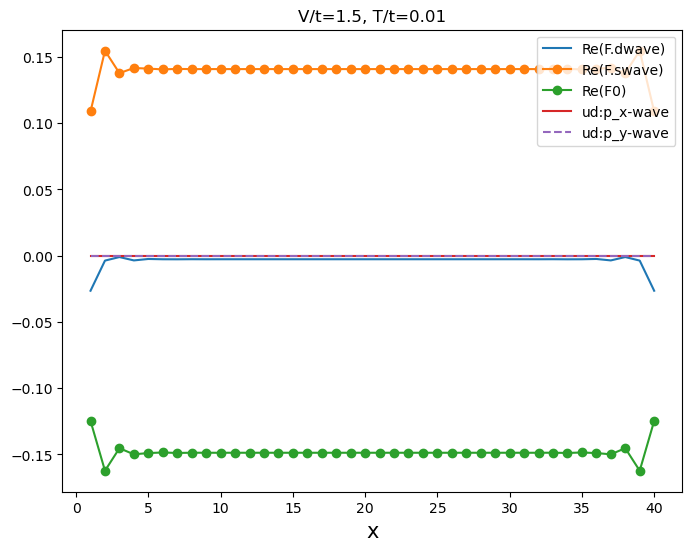

In [10]:
x = np.arange(1, widthD + 1)

fig, axs = plt.subplots(1, 1, figsize=(8, 6))
axs.set_title(f"V/t={V0}, T/t={T}")
axs.plot(x, np.real(F.dwave), label="Re(F.dwave)")
axs.plot(x, np.real(F.swave), '-o', label="Re(F.swave)")
axs.plot(x, np.real(H.F0), '-o', label="Re(F0)")
axs.plot(x, np.abs(F.px), label="ud:p_x-wave")
axs.plot(x, np.abs(F.py), "--", label="ud:p_y-wave")
axs.set_xlabel("x", fontsize=15)
# axs.axhline(0.33, linestyle='--', color="red")
axs.legend()
plt.show()

In [ ]:
print(F.dwave[X//2])

(-0.0014578864499658686+0j)


In [ ]:
temps = np.concatenate([
    np.arange(0.001, 0.009 + 1e-12, 0.001),
    np.arange(0.01, 0.61 + 1e-12, 0.01)
])  # 109 temps total
print(len(temps))

70


In [ ]:
width = 60
X, Y = width, 60
lattice = Lattice(X, Y)

t = 1
T = 0.01

muP = 1.8 * t
mu = np.ones(lattice.X) * muP

U = None
V_prime = None

V0 = 2 * t
V = V0 * np.ones(lattice.X)
H = Hamiltonian(t, mu, lattice, U=U, V_prime=V_prime, V=V,
                F_init=[0.1, -0.1, 0.1j, -0.1j])


In [ ]:
bdg_sc(H, atol=1e-3, rtol=0.1, maxiter=1000, temperature=T,verbose=True)
F, Fuu, Fdd = H.get_correlations()

F0:
Absolute error: 1.1457058431878386e-15
Relative error: 0.0011457058431878385
Average old: 0j
Average: (-5.0786924491561016e-18+0j)
F_xplus:
Absolute error: 0.3931383509644526
Relative error: 3.931383509605211
Average old: (0.09999999999999999+0j)
Average: (0.1504564722153526+0j)
F_xmin:
Absolute error: 0.39313835096445215
Relative error: 3.931383509683835
Average old: (-0.09999999999999999+0j)
Average: (-0.15045647221535255+0j)
F_yplus:
Absolute error: 0.41324026199859126
Relative error: 4.132402619985913
Average old: 0.10000000000000002j
Average: (3.737534982222945e-17+0.15304152928555753j)
F_ymin:
Absolute error: 0.41324026199859126
Relative error: 4.132402619985913
Average old: -0.10000000000000002j
Average: (3.737534982222945e-17-0.15304152928555753j)
Fuu_xplus:
Absolute error: 2.364887882678576e-16
Relative error: 0.00023648878826785754
Average old: 0j
Average: (-2.5142872724031836e-17+0j)
Fuu_xmin:
Absolute error: 2.9322839094892806e-16
Relative error: 0.00029322839094892805


KeyboardInterrupt: 

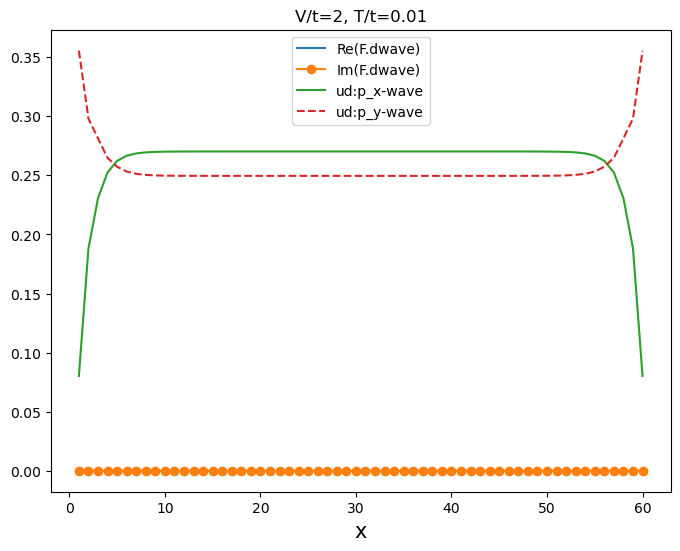

In [ ]:
x = np.arange(1, width + 1)

fig, axs = plt.subplots(1, 1, figsize=(8, 6))
axs.set_title(f"V/t={V0}, T/t={T}")
axs.plot(x, np.real(F.dwave), label="Re(F.dwave)")
axs.plot(x, np.imag(F.dwave), '-o', label="Im(F.dwave)")
axs.plot(x, np.abs(F.px), label="ud:p_x-wave")
axs.plot(x, np.abs(F.py), "--", label="ud:p_y-wave")
axs.set_xlabel("x", fontsize=15)
# axs.axhline(0.33, linestyle='--', color="red")
axs.legend()
plt.show()

In [ ]:
print(F.py[X//2])
print(F.px[X//2])


0.24956510115604053j
(0.2702341801986249+0j)
